# Spotify Churn Propensity Modeling

**Objective:** Build three logistic-regression models to answer key business questions about Spotify user retention:

1. **Which users are likely to become inactive?**
2. **Which free users are likely to subscribe?**
3. **Which premium users are at risk of canceling or downgrading?**

**Dataset:** [Spotify User Behavior and Pattern](https://www.kaggle.com/datasets/sahilislam007/spotify-user-behavior-and-pattern) (50,000 users)

**Tools:** pandas, scikit-learn, matplotlib

---

## 1. Setup & Data Loading

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, ConfusionMatrixDisplay,
)

%matplotlib inline
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

print("All imports loaded successfully.")

All imports loaded successfully.


In [2]:
import kagglehub

path = kagglehub.dataset_download("sahilislam007/spotify-user-behavior-and-pattern")
print("Path to dataset files:", path)

from pathlib import Path
csv_file = list(Path(path).glob("*.csv"))[0]
df = pd.read_csv(csv_file)
print(f"\nLoaded {len(df):,} rows × {len(df.columns)} columns")
df.head()

Path to dataset files: /Users/zacw/.cache/kagglehub/datasets/sahilislam007/spotify-user-behavior-and-pattern/versions/1

Loaded 50,000 rows × 18 columns


,user_id,country,age,signup_date,subscription_type,subscription_status,months_inactive,inactive_3_months_flag,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day
0,1,France,25,2021-08-19,Premium Duo,Active,0,0,No,No,4,10.13,Bollywood,Radio,Concert Alerts,Tablet,7,8
1,2,Indonesia,20,2022-06-06,Premium Family,Active,0,0,Yes,No,5,11.63,Latin,Podcasts,Lyrics Translation,Mobile,7,6
2,3,Italy,53,2024-01-04,Premium Individual,Active,0,0,Yes,Yes,3,9.50,Bollywood,Lyrics,Better AI Recommendations,Desktop,6,5
3,4,Italy,48,2018-08-26,Premium Individual,Active,1,0,No,No,4,13.16,Electronic,Playlists,Social Listening,Smart Speaker,11,8
4,5,Australia,18,2020-05-29,Free,Active,0,0,No,No,4,12.70,Indie,Daily Mix,Lyrics Translation,Tablet,10,11


## 2. Exploratory Data Analysis

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   user_id                         50000 non-null  int64  
 1   country                         50000 non-null  object 
 2   age                             50000 non-null  int64  
 3   signup_date                     50000 non-null  object 
 4   subscription_type               50000 non-null  object 
 5   subscription_status             50000 non-null  object 
 6   months_inactive                 50000 non-null  int64  
 7   inactive_3_months_flag          50000 non-null  int64  
 8   ad_interaction                  50000 non-null  object 
 9   ad_conversion_to_subscription   50000 non-null  object 
 10  music_suggestion_rating_1_to_5  50000 non-null  int64  
 11  avg_listening_hours_per_week    50000 non-null  float64
 12  favorite_genre                  

In [4]:
df.describe()

,user_id,age,months_inactive,inactive_3_months_flag,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,playlists_created,avg_skips_per_day
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,38.010280,1.533020,0.222460,3.644100,9.988986,8.002680,10.025920
std,14433.901067,12.984989,1.952082,0.415903,1.114424,3.968927,2.831571,3.165579
min,1.000000,16.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,12500.750000,27.000000,0.000000,0.000000,3.000000,7.280000,6.000000,8.000000
50%,25000.500000,38.000000,1.000000,0.000000,4.000000,9.980000,8.000000,10.000000
75%,37500.250000,49.000000,2.000000,0.000000,5.000000,12.680000,10.000000,12.000000
max,50000.000000,60.000000,18.000000,1.000000,5.000000,26.250000,23.000000,25.000000


In [5]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values per column:
user_id                           0
country                           0
age                               0
signup_date                       0
subscription_type                 0
subscription_status               0
months_inactive                   0
inactive_3_months_flag            0
ad_interaction                    0
ad_conversion_to_subscription     0
music_suggestion_rating_1_to_5    0
avg_listening_hours_per_week      0
favorite_genre                    0
most_liked_feature                0
desired_future_feature            0
primary_device                    0
playlists_created                 0
avg_skips_per_day                 0
dtype: int64

Total missing: 0


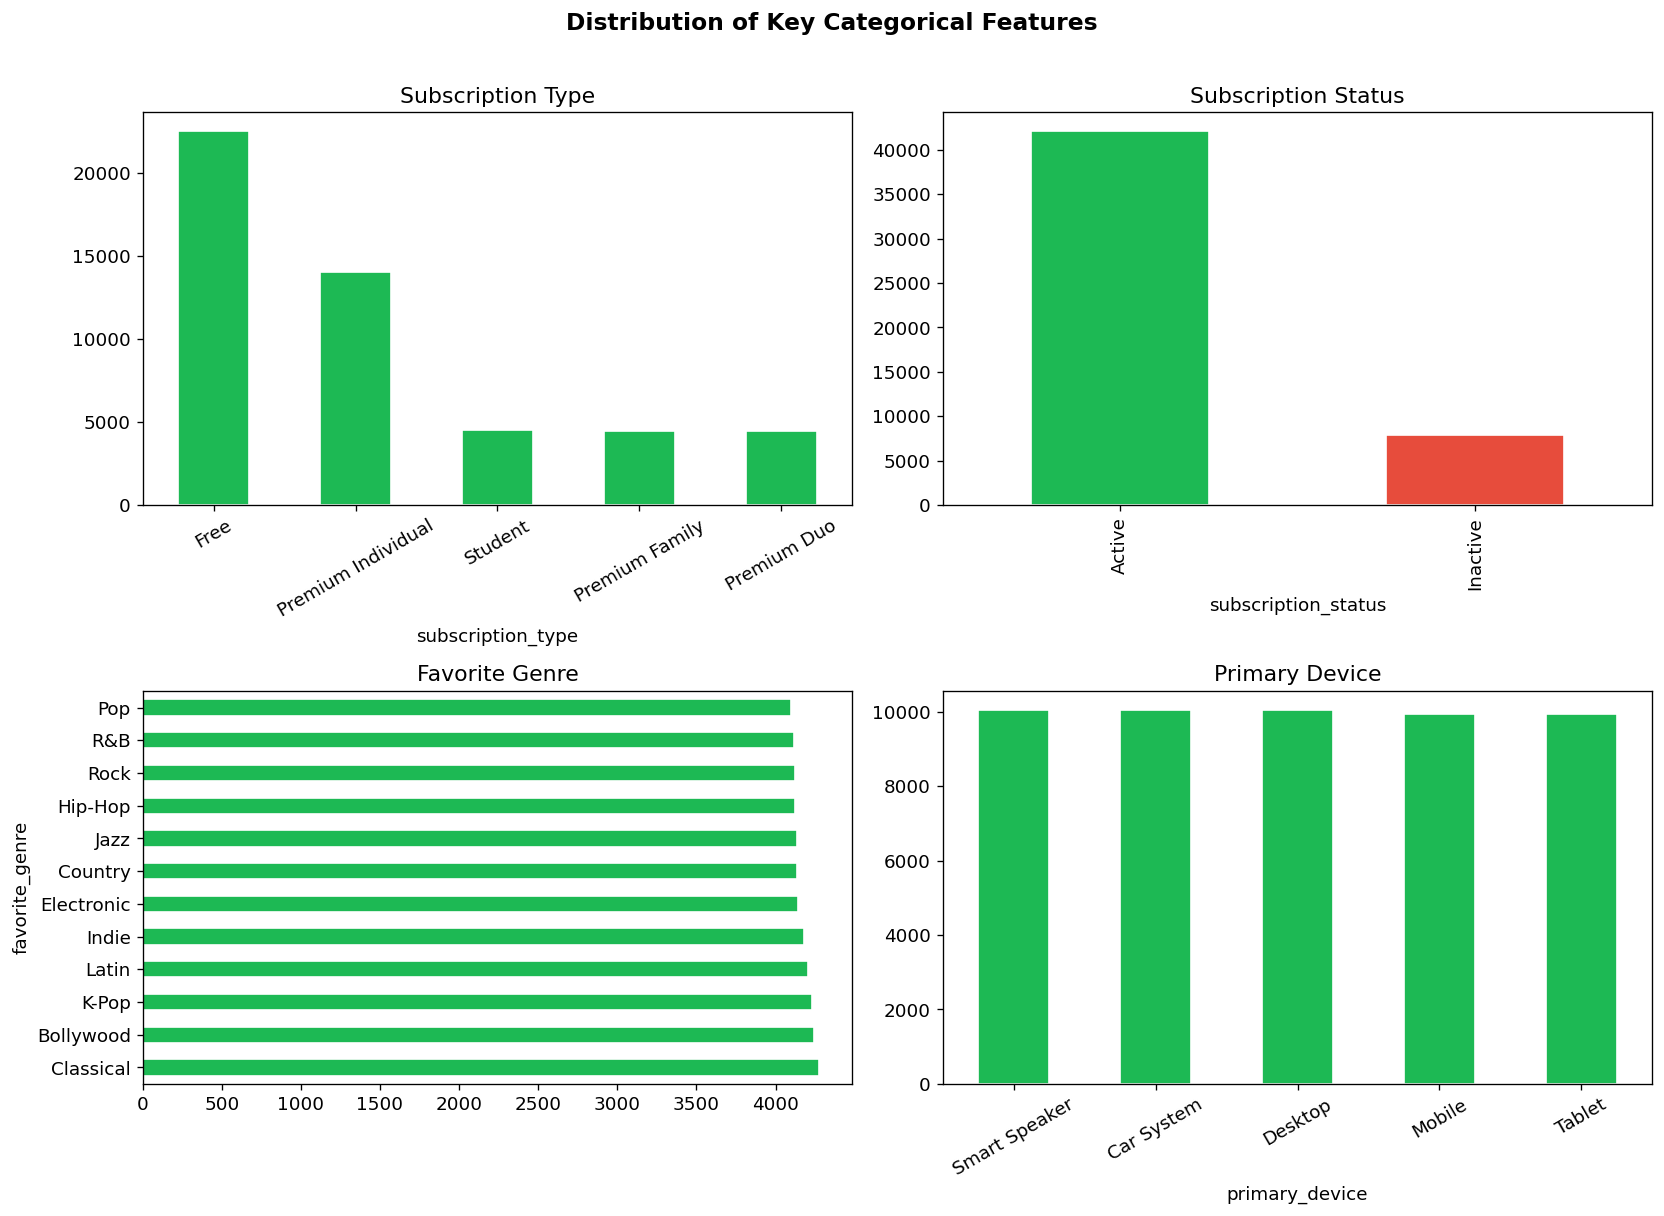

In [6]:
# Distribution of key categorical columns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df["subscription_type"].value_counts().plot.bar(ax=axes[0, 0], color="#1DB954", edgecolor="white")
axes[0, 0].set_title("Subscription Type")
axes[0, 0].tick_params(axis="x", rotation=30)

df["subscription_status"].value_counts().plot.bar(ax=axes[0, 1], color=["#1DB954", "#e74c3c"], edgecolor="white")
axes[0, 1].set_title("Subscription Status")

df["favorite_genre"].value_counts().plot.barh(ax=axes[1, 0], color="#1DB954", edgecolor="white")
axes[1, 0].set_title("Favorite Genre")

df["primary_device"].value_counts().plot.bar(ax=axes[1, 1], color="#1DB954", edgecolor="white")
axes[1, 1].set_title("Primary Device")
axes[1, 1].tick_params(axis="x", rotation=30)

fig.suptitle("Distribution of Key Categorical Features", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

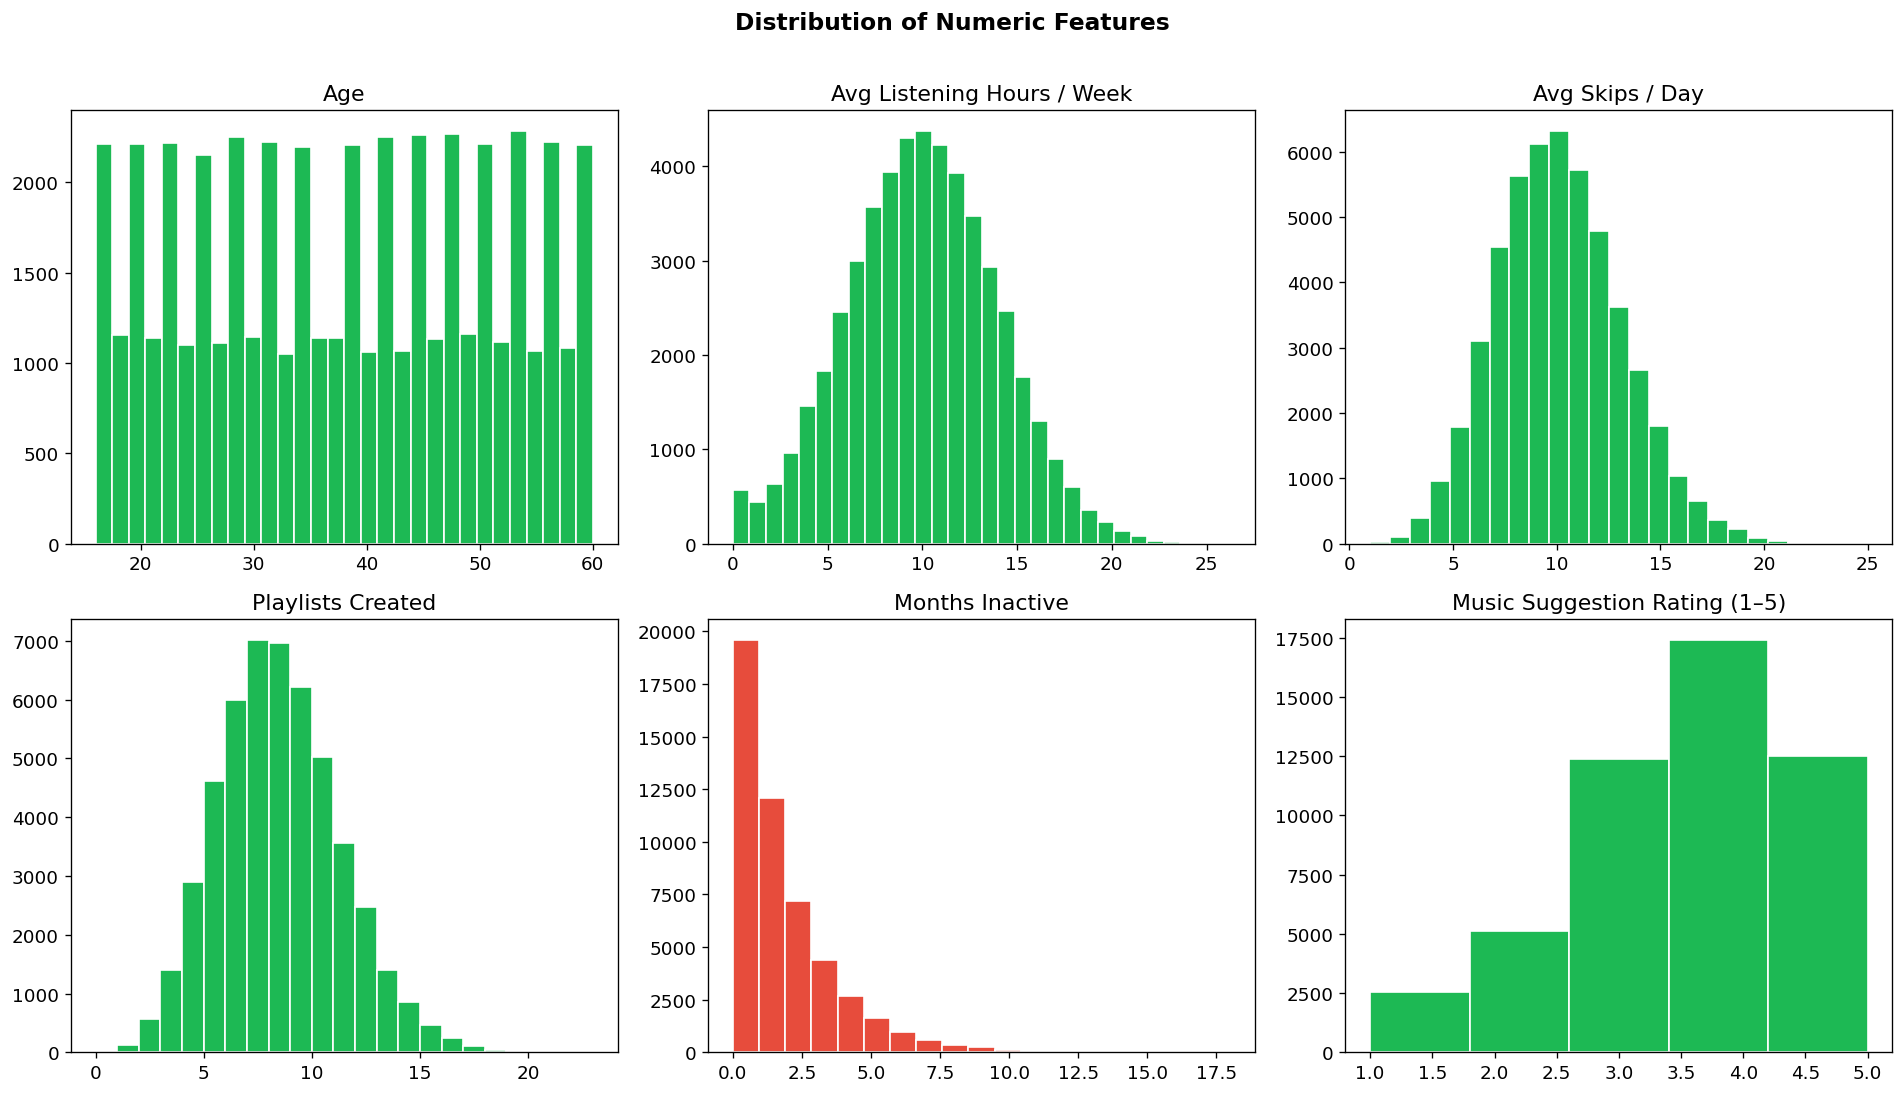

In [7]:
# Distribution of numeric features
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

axes[0, 0].hist(df["age"], bins=30, color="#1DB954", edgecolor="white")
axes[0, 0].set_title("Age")

axes[0, 1].hist(df["avg_listening_hours_per_week"], bins=30, color="#1DB954", edgecolor="white")
axes[0, 1].set_title("Avg Listening Hours / Week")

axes[0, 2].hist(df["avg_skips_per_day"], bins=25, color="#1DB954", edgecolor="white")
axes[0, 2].set_title("Avg Skips / Day")

axes[1, 0].hist(df["playlists_created"], bins=23, color="#1DB954", edgecolor="white")
axes[1, 0].set_title("Playlists Created")

axes[1, 1].hist(df["months_inactive"], bins=19, color="#e74c3c", edgecolor="white")
axes[1, 1].set_title("Months Inactive")

axes[1, 2].hist(df["music_suggestion_rating_1_to_5"], bins=5, color="#1DB954", edgecolor="white")
axes[1, 2].set_title("Music Suggestion Rating (1–5)")

fig.suptitle("Distribution of Numeric Features", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

In [8]:
# Target variable distributions
print("=== Target 1: Inactivity Flag (all users) ===")
print(df["inactive_3_months_flag"].value_counts())
print(f"Positive rate: {df['inactive_3_months_flag'].mean():.1%}")

print("\n=== Target 2: Ad Conversion to Subscription (Free users only) ===")
free_users = df[df["subscription_type"] == "Free"]
print(free_users["ad_conversion_to_subscription"].value_counts())
print(f"Positive rate: {(free_users['ad_conversion_to_subscription'] == 'Yes').mean():.1%}")

print("\n=== Target 3: Inactive Status (Premium users only) ===")
paid_tiers = ["Premium Individual", "Premium Duo", "Premium Family", "Student"]
premium_users = df[df["subscription_type"].isin(paid_tiers)]
print(premium_users["subscription_status"].value_counts())
print(f"Positive rate (Inactive): {(premium_users['subscription_status'] == 'Inactive').mean():.1%}")

=== Target 1: Inactivity Flag (all users) ===
inactive_3_months_flag
0    38877
1    11123
Name: count, dtype: int64
Positive rate: 22.2%

=== Target 2: Ad Conversion to Subscription (Free users only) ===
ad_conversion_to_subscription
No     20604
Yes     1921
Name: count, dtype: int64
Positive rate: 8.5%

=== Target 3: Inactive Status (Premium users only) ===
subscription_status
Active      23097
Inactive     4378
Name: count, dtype: int64
Positive rate (Inactive): 15.9%


## 3. Proxy Target Definitions

This dataset **does not contain true churn labels** with timestamps. We construct transparent proxy targets from the available columns:

| Model | Target Column | Definition | Rationale |
|-------|--------------|------------|-----------|
| **Inactivity Risk** | `inactive_3_months_flag` | 1 if user had 3+ consecutive months inactive | Directly provided in dataset — captures sustained disengagement |
| **Free → Subscribe** | `ad_conversion_to_subscription` | 1 if a Free user converted after an ad interaction | Proxy for willingness to pay — captures demonstrated conversion behavior |
| **Premium Churn** | `subscription_status` | 1 if a paid-plan user's status is "Inactive" | Inactive status on a paid plan indicates cancellation or downgrade |

> **Caveat:** These are *behavioral proxies*, not ground-truth churn events. Model outputs should be interpreted as relative propensity scores, not literal probabilities.

## 4. Feature Engineering

In [9]:
# Account tenure
df["signup_date"] = pd.to_datetime(df["signup_date"], errors="coerce")
snapshot_date = df["signup_date"].max() + pd.Timedelta(days=30)
df["account_age_days"] = (snapshot_date - df["signup_date"]).dt.days

# Premium flag
df["is_premium"] = (~df["subscription_type"].isin(["Free"])).astype(int)

# Engagement ratio: listening relative to skipping
df["listen_to_skip_ratio"] = df["avg_listening_hours_per_week"] / (df["avg_skips_per_day"] + 1)

print("Engineered features:")
print(f"  account_age_days     — mean: {df['account_age_days'].mean():.0f}, range: [{df['account_age_days'].min()}, {df['account_age_days'].max()}]")
print(f"  is_premium           — {df['is_premium'].mean():.1%} are premium")
print(f"  listen_to_skip_ratio — mean: {df['listen_to_skip_ratio'].mean():.2f}")
df[["account_age_days", "is_premium", "listen_to_skip_ratio"]].describe()

Engineered features:
  account_age_days     — mean: 1519, range: [30, 3011]
  is_premium           — 54.9% are premium
  listen_to_skip_ratio — mean: 1.00


,account_age_days,is_premium,listen_to_skip_ratio
count,50000.000000,50000.000000,50000.000000
mean,1518.873720,0.549500,0.995346
std,862.713043,0.497549,0.549518
min,30.000000,0.000000,0.000000
25%,774.000000,0.000000,0.633571
50%,1520.000000,1.000000,0.910833
75%,2263.000000,1.000000,1.251271
max,3011.000000,1.000000,9.765000


## 5. Reusable Preprocessing & Modeling Pipeline

We define helper functions for:
- **Dataset builders** — split features/targets for each task, dropping leakage columns
- **Preprocessor** — `StandardScaler` for numerics, `OneHotEncoder` for categoricals
- **Train & evaluate** — fit logistic regression, compute all metrics, extract top coefficients

In [10]:
# Columns to always exclude from features (identifiers, targets, leakage)
DROP_ALWAYS = [
    "user_id", "signup_date", "subscription_status",
    "inactive_3_months_flag", "months_inactive",
    "ad_conversion_to_subscription",
]

def feature_cols(dataframe):
    return [c for c in dataframe.columns if c not in DROP_ALWAYS]

def build_preprocessor(X):
    """ColumnTransformer: scale numerics, one-hot encode categoricals."""
    num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
    cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ],
        remainder="drop",
    )

def get_feature_names(preprocessor):
    """Extract feature names from a fitted ColumnTransformer."""
    names = []
    for name, trans, cols in preprocessor.transformers_:
        if name == "remainder":
            continue
        if hasattr(trans, "get_feature_names_out"):
            names.extend(trans.get_feature_names_out(cols))
        else:
            names.extend(cols)
    return list(names)

def train_and_evaluate(X, y, task_name, test_size=0.2, random_state=42):
    """Full pipeline: preprocess → train → evaluate → return results dict."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y,
    )
    preprocessor = build_preprocessor(X_train)
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000, solver="lbfgs",
            class_weight="balanced", random_state=random_state,
        )),
    ])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    feat_names = get_feature_names(pipe.named_steps["preprocessor"])
    coefs = pipe.named_steps["classifier"].coef_[0]
    coef_df = (
        pd.DataFrame({"feature": feat_names, "coefficient": coefs})
        .sort_values("coefficient", key=abs, ascending=False)
        .head(15)
    )

    return {
        "task": task_name,
        "pipeline": pipe,
        "X_test": X_test, "y_test": y_test, "y_pred": y_pred, "y_prob": y_prob,
        "n_train": len(X_train), "n_test": len(X_test),
        "pos_rate": float(y_train.mean()),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "cm": confusion_matrix(y_test, y_pred),
        "top_coefs": coef_df,
    }

print("Pipeline functions defined.")

Pipeline functions defined.


In [11]:
def plot_model_results(results):
    """Plot ROC curve, confusion matrix, and top coefficients side by side."""
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    
    # ROC Curve
    RocCurveDisplay.from_predictions(
        results["y_test"], results["y_prob"], ax=axes[0], name=results["task"]
    )
    axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
    axes[0].set_title(f"ROC Curve — AUC = {results['roc_auc']:.4f}")
    
    # Confusion Matrix
    ConfusionMatrixDisplay(results["cm"], display_labels=["Negative", "Positive"]).plot(
        ax=axes[1], cmap="Blues"
    )
    axes[1].set_title("Confusion Matrix")
    
    # Top Coefficients
    coef_df = results["top_coefs"].sort_values("coefficient")
    colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in coef_df["coefficient"]]
    axes[2].barh(coef_df["feature"], coef_df["coefficient"], color=colors)
    axes[2].axvline(0, color="black", linewidth=0.5)
    axes[2].set_title("Top 15 Feature Coefficients")
    axes[2].set_xlabel("Coefficient")
    
    fig.suptitle(results["task"], fontsize=15, fontweight="bold", y=1.03)
    fig.tight_layout()
    plt.show()

def print_metrics(results):
    """Print formatted metrics table."""
    print(f"  Train size: {results['n_train']:,}  |  Test size: {results['n_test']:,}")
    print(f"  Positive rate (train): {results['pos_rate']:.1%}")
    print(f"  {'─'*40}")
    print(f"  ROC-AUC   : {results['roc_auc']:.4f}")
    print(f"  Precision : {results['precision']:.4f}")
    print(f"  Recall    : {results['recall']:.4f}")
    print(f"  F1 Score  : {results['f1']:.4f}")
    print(f"\n{classification_report(results['y_test'], results['y_pred'])}")

print("Visualization functions defined.")

Visualization functions defined.


---

## 6. Model 1 — Inactivity Risk

**Question:** Which users are likely to become inactive?

**Target:** `inactive_3_months_flag` (1 = user was inactive for 3+ consecutive months)

**Population:** All 50,000 users

In [12]:
# Build dataset
X_inact = df[feature_cols(df)]
y_inact = df["inactive_3_months_flag"]

print(f"Features: {X_inact.shape[1]} columns, {len(X_inact):,} rows")
print(f"Target balance: {y_inact.value_counts().to_dict()}")

# Train & evaluate
results_inactivity = train_and_evaluate(X_inact, y_inact, "Inactivity Risk")
print_metrics(results_inactivity)

Features: 15 columns, 50,000 rows
Target balance: {0: 38877, 1: 11123}
  Train size: 40,000  |  Test size: 10,000
  Positive rate (train): 22.2%
  ────────────────────────────────────────
  ROC-AUC   : 0.5022
  Precision : 0.2197
  Recall    : 0.4876
  F1 Score  : 0.3029

              precision    recall  f1-score   support

           0       0.77      0.50      0.61      7775
           1       0.22      0.49      0.30      2225

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.46     10000
weighted avg       0.65      0.50      0.54     10000



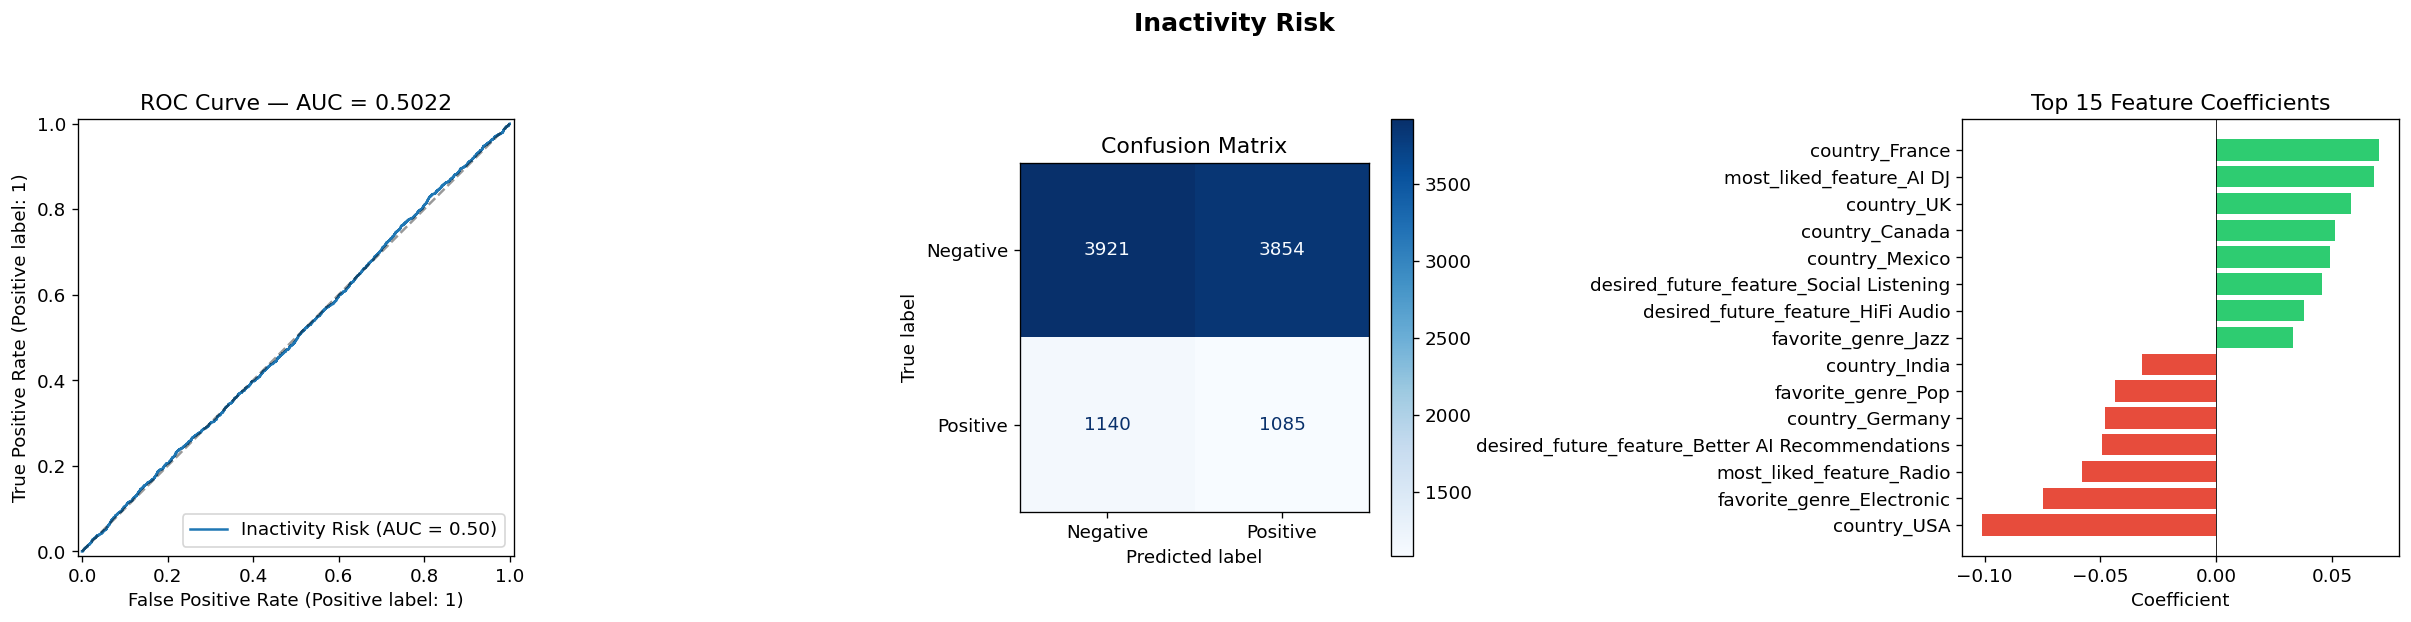

In [13]:
plot_model_results(results_inactivity)

**Findings — Inactivity Risk:**
- **AUC ≈ 0.50** — the model performs at random chance
- The behavioral features in this dataset have **no meaningful linear correlation** with the inactivity flag
- This strongly suggests the `inactive_3_months_flag` was assigned independently of user behavior during synthetic data generation
- In a real-world setting, predicting inactivity requires **longitudinal engagement signals** (e.g., week-over-week listening decline, session frequency drops)

---

## 7. Model 2 — Free-to-Subscribe Conversion

**Question:** Which free users are likely to subscribe?

**Target:** `ad_conversion_to_subscription` (1 = Free user converted after an ad interaction)

**Population:** 22,525 Free-tier users only

In [14]:
# Build dataset — Free users only
mask_free = df["subscription_type"] == "Free"
X_free = df.loc[mask_free, feature_cols(df)]
y_free = (df.loc[mask_free, "ad_conversion_to_subscription"] == "Yes").astype(int)

print(f"Features: {X_free.shape[1]} columns, {len(X_free):,} rows")
print(f"Target balance: {y_free.value_counts().to_dict()}")

# Train & evaluate
results_conversion = train_and_evaluate(X_free, y_free, "Free to Subscribe")
print_metrics(results_conversion)

Features: 15 columns, 22,525 rows
Target balance: {0: 20604, 1: 1921}
  Train size: 18,020  |  Test size: 4,505
  Positive rate (train): 8.5%
  ────────────────────────────────────────
  ROC-AUC   : 0.8520
  Precision : 0.2402
  Recall    : 1.0000
  F1 Score  : 0.3873

              precision    recall  f1-score   support

           0       1.00      0.71      0.83      4121
           1       0.24      1.00      0.39       384

    accuracy                           0.73      4505
   macro avg       0.62      0.85      0.61      4505
weighted avg       0.94      0.73      0.79      4505



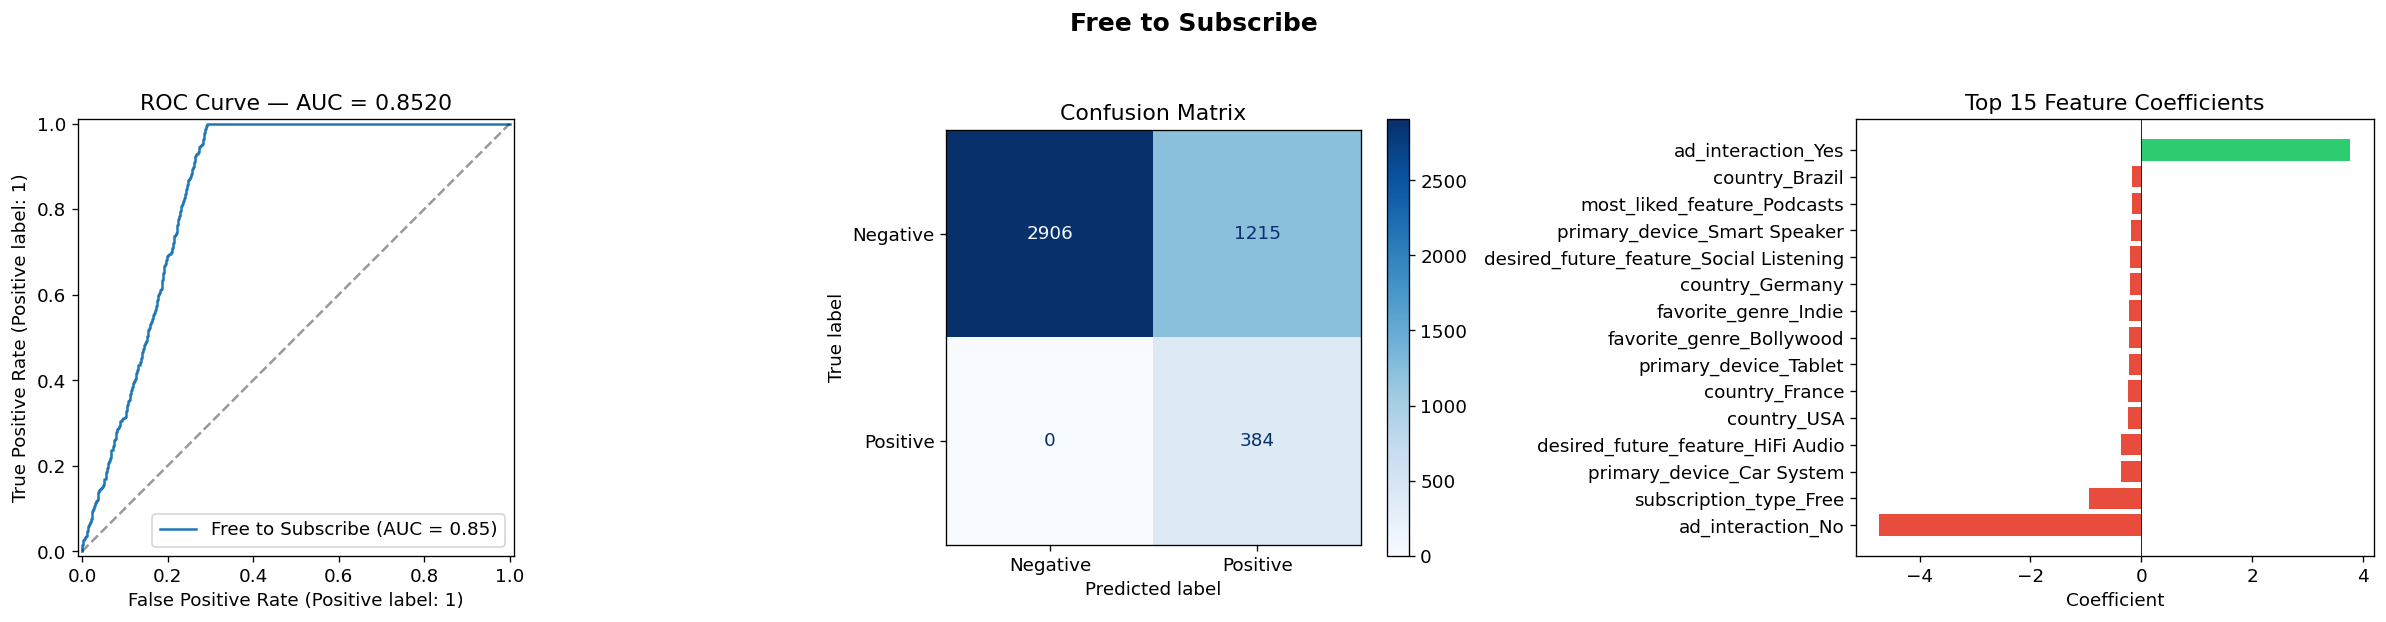

In [15]:
plot_model_results(results_conversion)

**Findings — Free to Subscribe:**
- **AUC = 0.85** — strong discriminative power; this is the best-performing model
- **Recall = 1.00** — the model catches every converter, but at the cost of precision (0.24), meaning it also flags many non-converters
- **Top predictor: `ad_interaction`** — this logically gates conversion (you can't convert from an ad you never interacted with)
- This model is **directly actionable**: use propensity scores to prioritize premium trial offers, in-app upgrade prompts, and targeted ad campaigns toward high-score Free users

---

## 8. Model 3 — Premium Churn Risk

**Question:** Which premium users are at risk of canceling or downgrading?

**Target:** `subscription_status == "Inactive"` among paid-plan users

**Population:** 27,475 users on Premium Individual, Premium Duo, Premium Family, or Student plans

In [16]:
# Build dataset — paid-plan users only
paid_tiers = ["Premium Individual", "Premium Duo", "Premium Family", "Student"]
mask_paid = df["subscription_type"].isin(paid_tiers)
X_prem = df.loc[mask_paid, feature_cols(df)]
y_prem = (df.loc[mask_paid, "subscription_status"] == "Inactive").astype(int)

print(f"Features: {X_prem.shape[1]} columns, {len(X_prem):,} rows")
print(f"Target balance: {y_prem.value_counts().to_dict()}")

# Train & evaluate
results_churn = train_and_evaluate(X_prem, y_prem, "Premium Churn Risk")
print_metrics(results_churn)

Features: 15 columns, 27,475 rows
Target balance: {0: 23097, 1: 4378}


  Train size: 21,980  |  Test size: 5,495
  Positive rate (train): 15.9%
  ────────────────────────────────────────
  ROC-AUC   : 0.4990
  Precision : 0.1651
  Recall    : 0.5080
  F1 Score  : 0.2492

              precision    recall  f1-score   support

           0       0.85      0.51      0.64      4619
           1       0.17      0.51      0.25       876

    accuracy                           0.51      5495
   macro avg       0.51      0.51      0.44      5495
weighted avg       0.74      0.51      0.58      5495



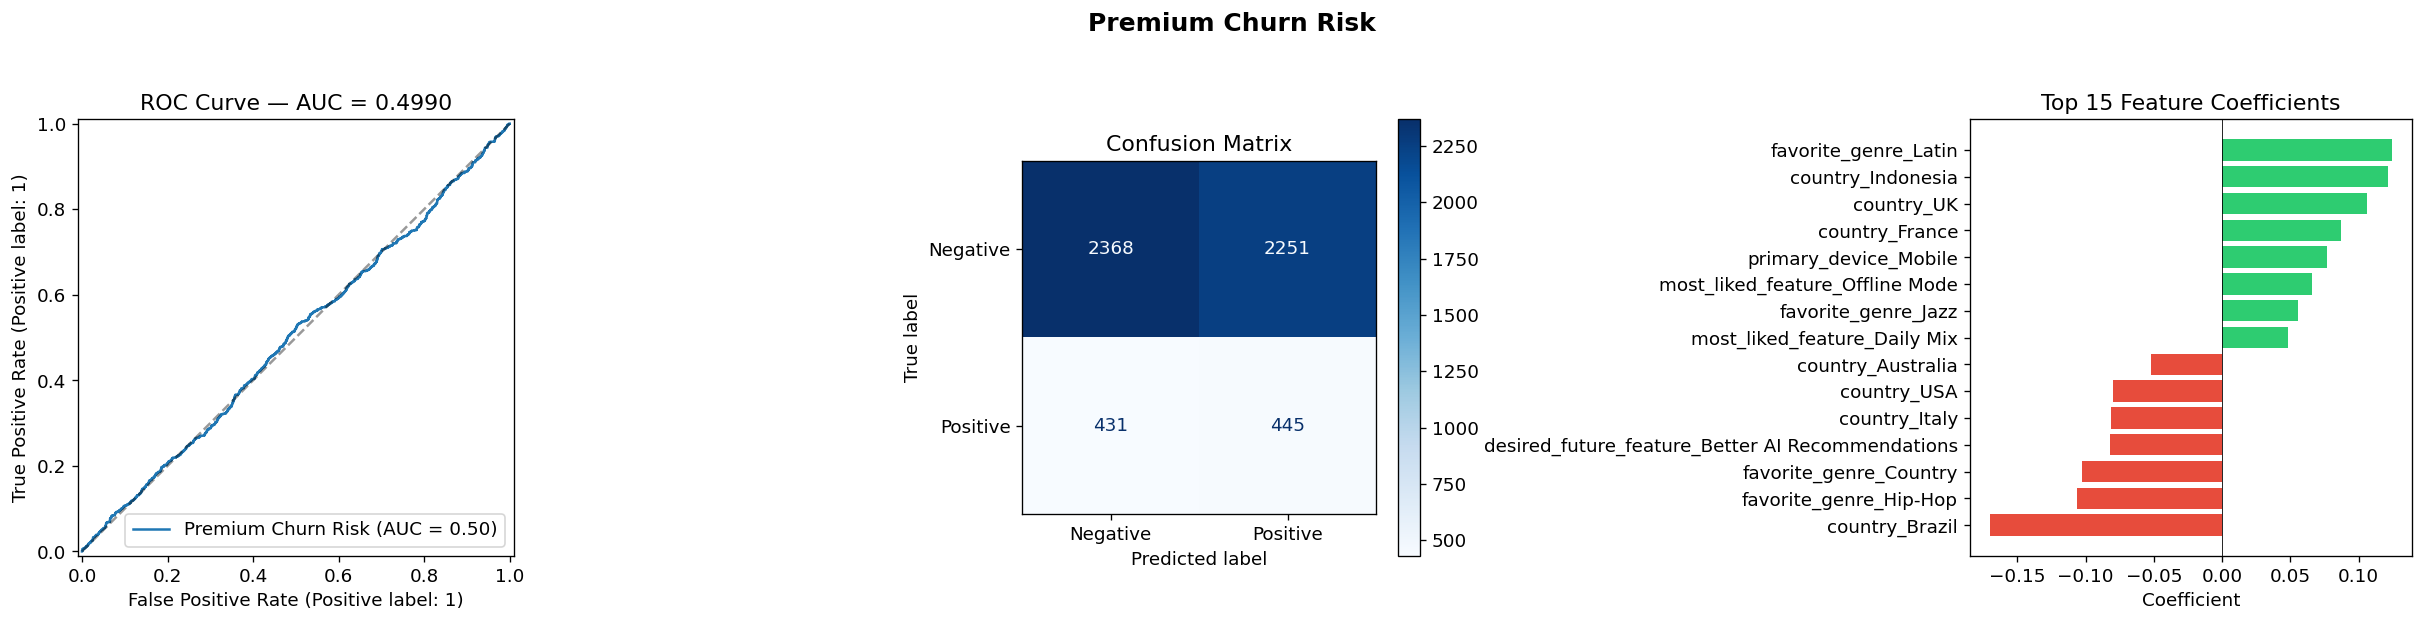

In [17]:
plot_model_results(results_churn)

**Findings — Premium Churn Risk:**
- **AUC ≈ 0.50** — effectively random, same pattern as the Inactivity model
- The behavioral and demographic features available **cannot distinguish churners from non-churners** on paid plans
- Same root cause: the `subscription_status` label appears independent of behavioral columns in this synthetic dataset
- A production model would need **payment failure events, support tickets, usage trend declines, and renewal/cancellation timestamps**

---

## 9. Summary Comparison

In [18]:
# Side-by-side metrics comparison
summary = pd.DataFrame([
    {
        "Model": r["task"],
        "Population": f'{r["n_train"] + r["n_test"]:,}',
        "Positive Rate": f'{r["pos_rate"]:.1%}',
        "ROC-AUC": f'{r["roc_auc"]:.4f}',
        "Precision": f'{r["precision"]:.4f}',
        "Recall": f'{r["recall"]:.4f}',
        "F1": f'{r["f1"]:.4f}',
    }
    for r in [results_inactivity, results_conversion, results_churn]
])
summary.set_index("Model", inplace=True)
summary

,Population,Positive Rate,ROC-AUC,Precision,Recall,F1
Model,,,,,,
Inactivity Risk,"50,000",22.2%,0.5022,0.2197,0.4876,0.3029
Free to Subscribe,"22,525",8.5%,0.8520,0.2402,1.0000,0.3873
Premium Churn Risk,"27,475",15.9%,0.4990,0.1651,0.5080,0.2492


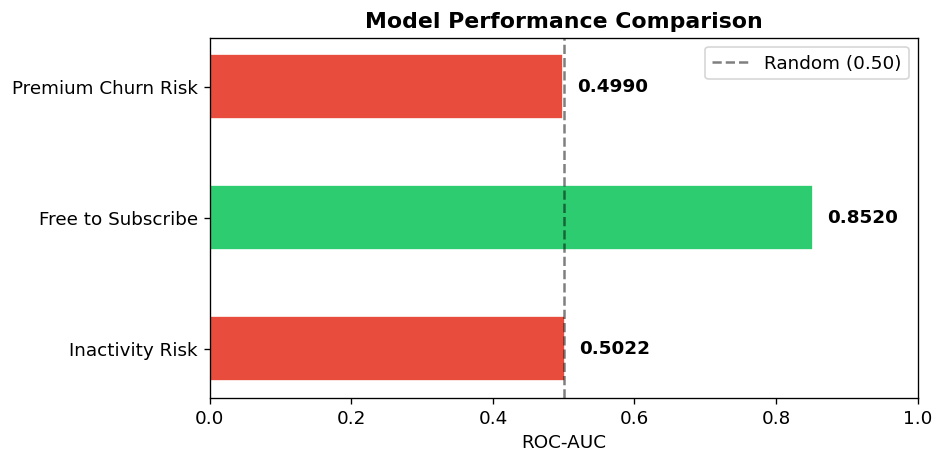

In [19]:
# Visual comparison of AUC scores
fig, ax = plt.subplots(figsize=(8, 4))
models = [r["task"] for r in [results_inactivity, results_conversion, results_churn]]
aucs = [r["roc_auc"] for r in [results_inactivity, results_conversion, results_churn]]
colors = ["#e74c3c" if a < 0.55 else "#2ecc71" for a in aucs]

bars = ax.barh(models, aucs, color=colors, edgecolor="white", height=0.5)
ax.axvline(0.5, color="black", linestyle="--", alpha=0.5, label="Random (0.50)")
ax.set_xlim(0, 1)
ax.set_xlabel("ROC-AUC")
ax.set_title("Model Performance Comparison", fontweight="bold")
ax.legend()

for bar, auc in zip(bars, aucs):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, 
            f"{auc:.4f}", va="center", fontweight="bold")

fig.tight_layout()
plt.show()

---

## 10. Business Recommendations

### Actionable Now
1. **Free-to-Paid Conversion (AUC = 0.85):** Use propensity scores to rank Free users by subscribe likelihood. Target the top decile with:
   - Premium free-trial offers
   - Reduced-friction upgrade flows
   - Personalized ad campaigns highlighting premium features they'd value

### Requires Better Data
2. **Inactivity Prevention & Premium Retention:** The near-random AUC on these models is an honest signal — **the available cross-sectional features cannot predict churn**. To build production-grade models, invest in collecting:
   - Session-level engagement logs (daily/weekly active usage trends)
   - Listening streak and dropout patterns over time
   - Support ticket / complaint history
   - Payment failure events and renewal timestamps

### Product Insight
3. **Ad interaction is the dominant conversion signal.** Improving ad targeting quality, ad creative relevance, and ad-to-trial funnels is the highest-leverage investment this data supports.

---

## 11. Caveats & Limitations

| Limitation | Impact |
|-----------|--------|
| **Proxy targets, not true churn labels** | Models learn correlates of the proxy, not causal drivers |
| **Synthetic dataset** | Two models at random AUC suggest labels were assigned independently of behavior |
| **Cross-sectional snapshot** | No temporal dynamics — a real model needs time-series features |
| **Logistic regression only** | Chosen for interpretability; ensemble methods could improve AUC but won't fix data limitations |
| **No temporal validation** | 80/20 random split, not time-based — production would need forward-looking holdout |